<a href="https://colab.research.google.com/github/pranita30012005/ChronicDiseaseRiskAnalysis/blob/main/Day_3_EDA_on_Diabetes_Risk_Dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
Day 3 - EDA on Diabetes Risk Dataset
"""


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

In [7]:
DATA_PATH = "/content/drive/MyDrive/ChronicDiseaseRiskAnalysis/data/raw/diabetes.csv"          # <-- update path if needed
IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

FEATURES = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
TARGET = "Outcome"

print(df.shape)
print(df.head())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Basic health check & # Hidden missing values (biologically impossible zeros)

In [8]:

print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe().T)


zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[zero_as_missing] == 0).sum()
print("Suspicious zero-value counts (likely missing data):\n", zero_counts)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction  

# 1. Class balance

/tmp/ipykernel_2426/2172914774.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Diabetic (0)", "Diabetic (1)"])


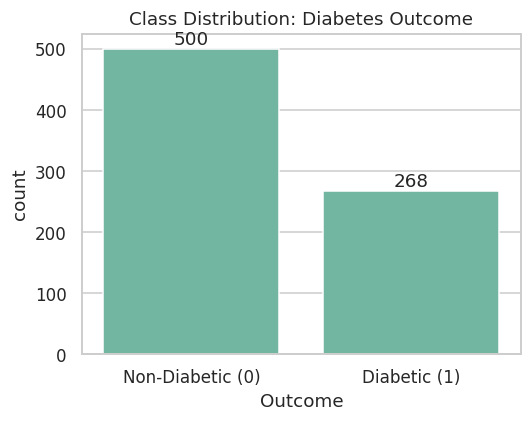

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64 % split


In [9]:

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=TARGET, ax=ax)
ax.set_xticklabels(["Non-Diabetic (0)", "Diabetic (1)"])
ax.set_title("Class Distribution: Diabetes Outcome")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/01_class_balance.png")
plt.show()
print(df[TARGET].value_counts(normalize=True).round(3) * 100, "% split")

2. Histograms of all features

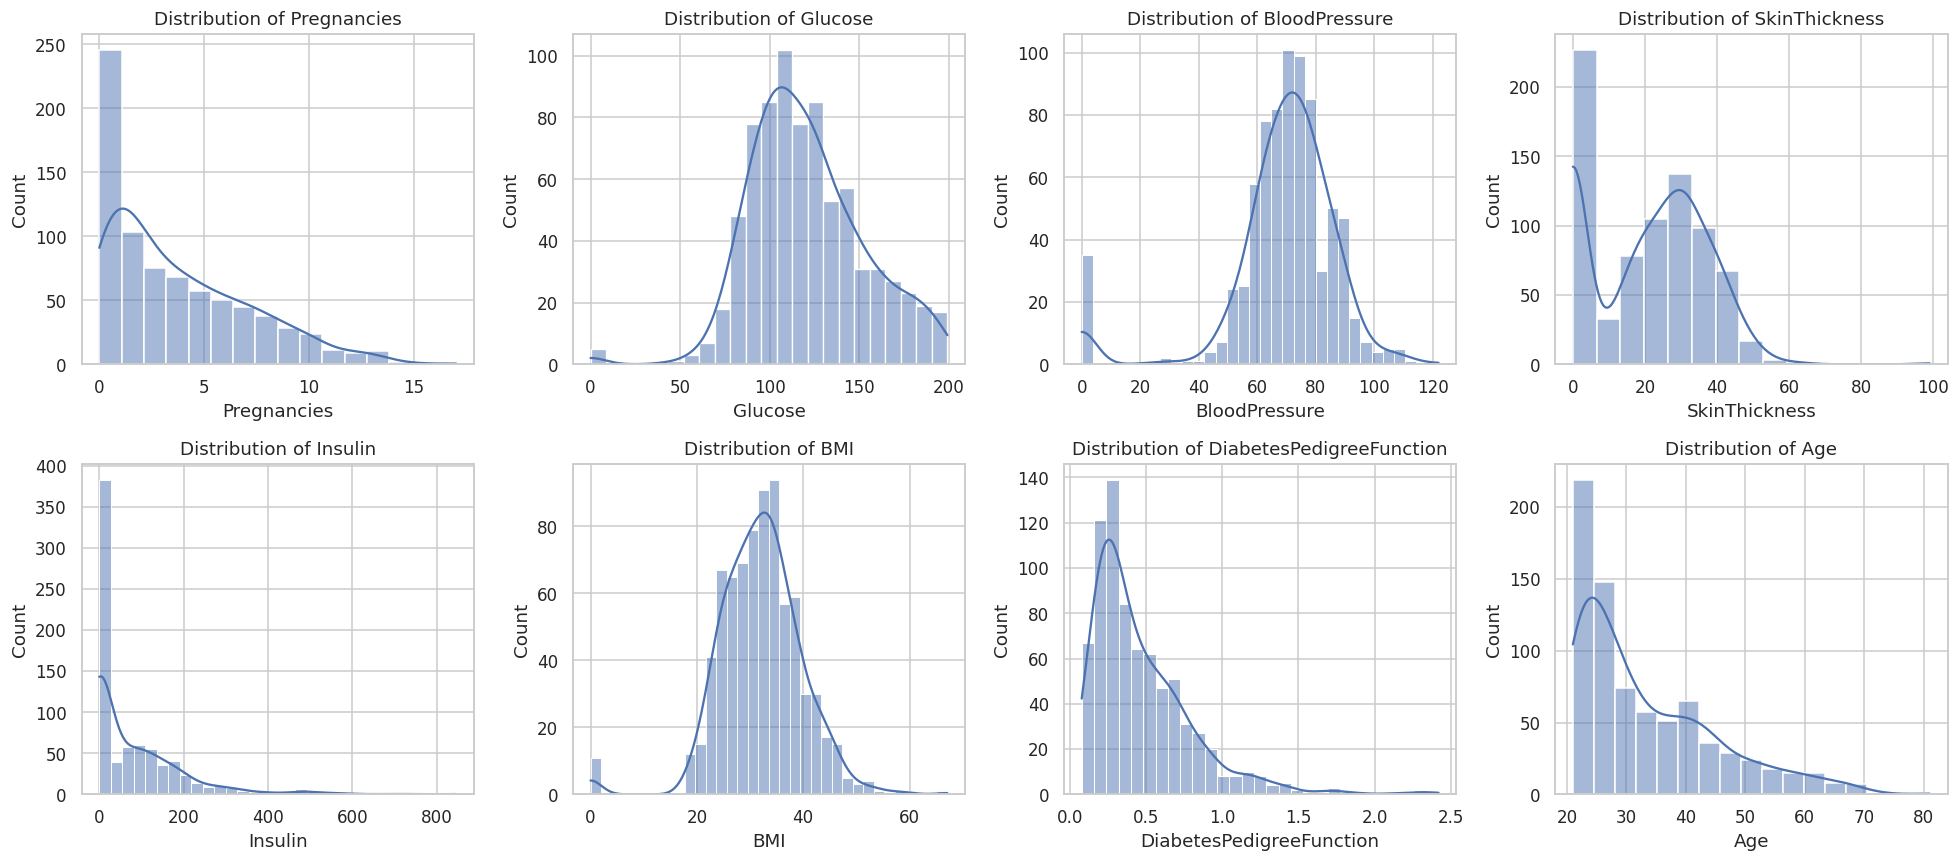

In [10]:

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/02_histograms_all_features.png")
plt.show()


3. Boxplots: Glucose & BMI by Outcome

/tmp/ipykernel_2426/2406267538.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Non-Diabetic", "Diabetic"])
/tmp/ipykernel_2426/2406267538.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Non-Diabetic", "Diabetic"])


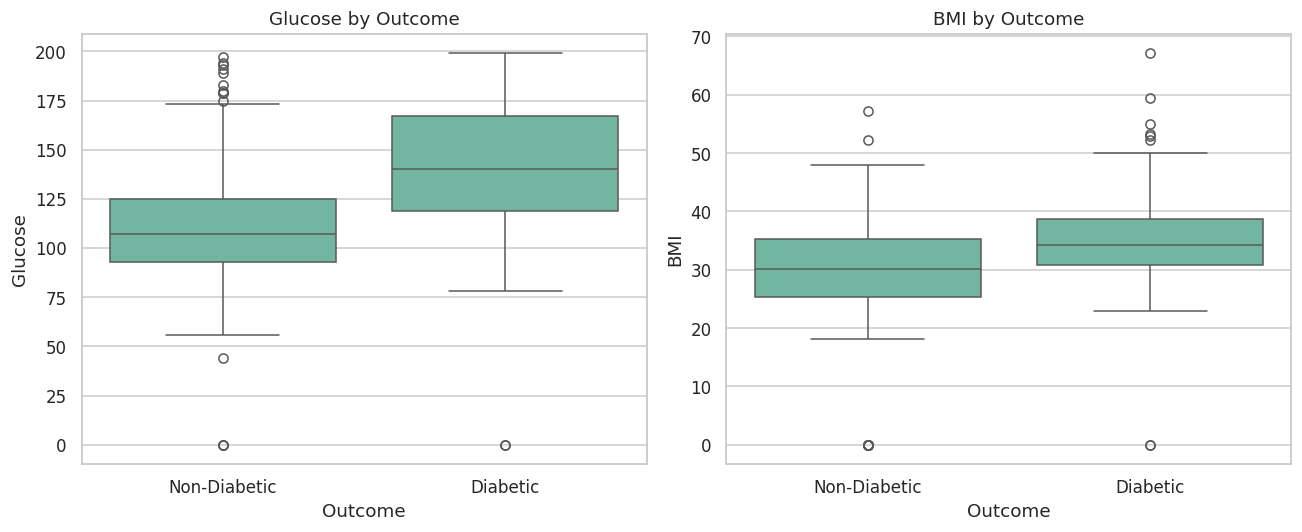

In [11]:
-
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x=TARGET, y="Glucose", ax=axes[0])
axes[0].set_xticklabels(["Non-Diabetic", "Diabetic"])
axes[0].set_title("Glucose by Outcome")
sns.boxplot(data=df, x=TARGET, y="BMI", ax=axes[1])
axes[1].set_xticklabels(["Non-Diabetic", "Diabetic"])
axes[1].set_title("BMI by Outcome")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/03_boxplots_glucose_bmi.png")
plt.show()

4. Violin plot: Age by Outcome

/tmp/ipykernel_2426/2959345772.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Diabetic", "Diabetic"])


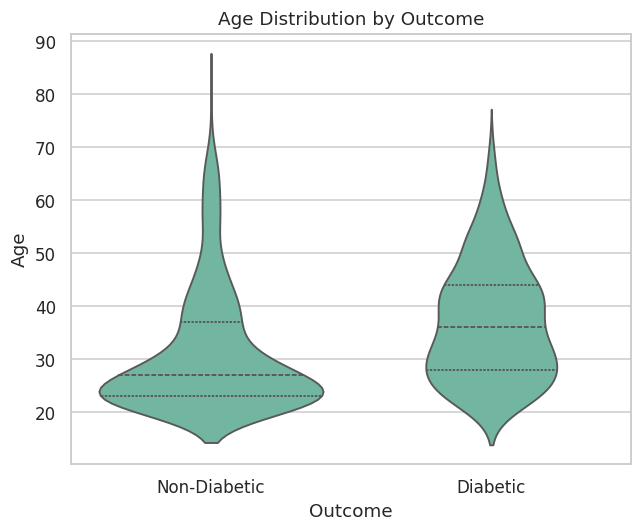

In [14]:

fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df, x=TARGET, y="Age", ax=ax, inner="quartile")
ax.set_xticklabels(["Non-Diabetic", "Diabetic"])
ax.set_title("Age Distribution by Outcome")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/04_violin_age_outcome.png")
plt.show()

5. Count plot: Pregnancy buckets by Outcome

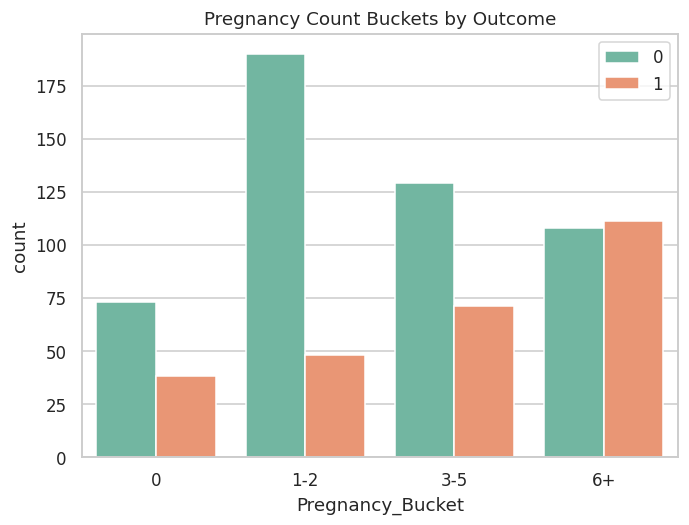

In [16]:

df["Pregnancy_Bucket"] = pd.cut(df["Pregnancies"], bins=[-1, 0, 2, 5, 100],
                                labels=["0", "1-2", "3-5", "6+"])
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="Pregnancy_Bucket", hue=TARGET, ax=ax)
ax.set_title("Pregnancy Count Buckets by Outcome")
ax.legend()